# 🔬 Extraction du ratio mm/px par analyse de Fourier

## Objectif
Ce notebook analyse une image d'insecte accompagnée d'une règle graduée.
L'algorithme détecte automatiquement les graduations de la règle via une **Transformée de Fourier**
appliquée ligne par ligne, puis corrige l'angle d'inclinaison éventuel de la règle par trigonométrie.

## Algorithme en résumé
1. Charger l'image en niveaux de gris
2. Appliquer la FFT sur chaque ligne de pixels
3. Détecter le pic dominant → fréquence = 1 graduation/px
4. Estimer l'angle d'inclinaison de la règle via la dérive de phase entre lignes
5. Corriger le ratio px/mm avec la trigonométrie
6. Afficher les résultats

In [1]:
# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from scipy.stats import circmean
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Style global des graphiques
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'monospace'

print("✅ Imports OK")

✅ Imports OK


In [103]:
# ─────────────────────────────────────────────
# 2. PARAMÈTRES UTILISATEUR
# ─────────────────────────────────────────────

# 📂 Chemin vers l'image à analyser
#IMAGE_PATH = "../databases/luomus_pictures_1/8/F.8368.jpg"   # ← modifier ici
IMAGE_PATH =  "D:\\luomus_pictures\\luomus_pictures_5\\F.573365.jpg"

# Pas de graduation de la règle en mm
# (ex: 1.0 si les traits sont espacés de 1 mm, 0.5 si de 0.5 mm, etc.)
GRADUATION_MM = 1.0   # ← modifier selon votre règle

# Paramètres de détection FFT
MIN_FREQ_PX = 5        # Distance minimale entre graduations en px (évite les artefacts BF)
MAX_FREQ_PX = 500      # Distance maximale entre graduations en px
PEAK_PROMINENCE = 0.1  # Proéminence minimale du pic FFT (0→1, relatif au max)

# Nombre de lignes à analyser (None = toutes)
# Réduire pour accélérer sur de grandes images
N_LINES = None         # ex: 200 pour n'analyser que 200 lignes

print(f"⚙️  Graduation attendue : {GRADUATION_MM} mm")
print(f"⚙️  Plage de périodes valides : [{MIN_FREQ_PX} – {MAX_FREQ_PX}] px")

⚙️  Graduation attendue : 1.0 mm
⚙️  Plage de périodes valides : [5 – 500] px


📐 Taille de l'image : 7360 × 4912 px


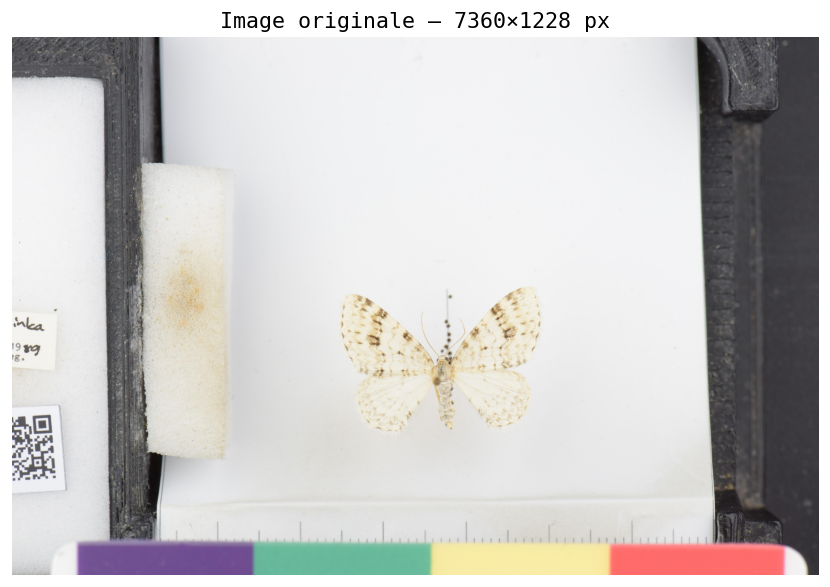

In [104]:
# ─────────────────────────────────────────────
# 3. CHARGEMENT & PRÉPARATION DE L'IMAGE
# ─────────────────────────────────────────────

def load_image(path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Charge une image et retourne :
      - img_gray  : tableau 2D float32 en niveaux de gris [0,1]
      - img_color : tableau 3D uint8 RGB pour affichage
    """
    img = Image.open(path).convert("RGB")
    img_color = np.array(img)

    # Conversion en niveaux de gris (luminance ITU-R BT.601)
    img_gray = np.dot(img_color[..., :3], [0.299, 0.587, 0.114]).astype(np.float32) / 255.0

    print(f"📐 Taille de l'image : {img_gray.shape[1]} × {img_gray.shape[0]} px")
    return img_gray, img_color


base_img_gray, base_img_color = load_image(IMAGE_PATH)
# get only the 25% last lines of the image, where the ruler is located
img_gray = base_img_gray[int(0.75*base_img_gray.shape[0]):, :]
img_color = base_img_color[int(0.75*base_img_color.shape[0]):, :, :]
H, W = img_gray.shape

# Aperçu de l'image
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(base_img_color)
ax.set_title(f"Image originale — {W}×{H} px", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [105]:
# ─────────────────────────────────────────────
# 4. ANALYSE FFT LIGNE PAR LIGNE
# ─────────────────────────────────────────────

def fft_dominant_frequency(row: np.ndarray,
                            min_period_px: int,
                            max_period_px: int,
                            prominence: float) -> tuple[float | None, float | None]:
    """
    Applique la FFT sur une ligne de pixels et retourne
    la période dominante (en px) et sa phase.

    Paramètres
    ----------
    row           : 1D array de niveaux de gris
    min_period_px : période minimale acceptée (px)
    max_period_px : période maximale acceptée (px)
    prominence    : proéminence relative minimale du pic

    Retourne
    --------
    (période_px, phase_rad) ou (None, None) si aucun pic valide
    """
    N = len(row)

    # Soustraire la moyenne pour annuler la composante continue (DC)
    row_centered = row - row.mean()

    # Appliquer une fenêtre de Hann pour réduire les artefacts de bord
    window = np.hanning(N)
    row_windowed = row_centered * window

    # Transformée de Fourier
    fft_vals = np.fft.rfft(row_windowed)
    freqs    = np.fft.rfftfreq(N)   # fréquences normalisées [0, 0.5]

    # Magnitude du spectre
    magnitude = np.abs(fft_vals)

    # Convertir les limites de période en indices de fréquence
    # freq = 1/période_px  ⟹  f_min = 1/max_period, f_max = 1/min_period
    f_min = 1.0 / max_period_px
    f_max = 1.0 / min_period_px

    # Masquer les fréquences hors plage
    mask = (freqs >= f_min) & (freqs <= f_max)
    if mask.sum() == 0:
        return None, None

    mag_masked = magnitude.copy()
    mag_masked[~mask] = 0

    # Détection du pic le plus proéminent dans la plage valide
    peaks, props = find_peaks(mag_masked,
                              prominence=prominence * mag_masked.max())
    if len(peaks) == 0:
        return None, None

    # Pic d'amplitude maximale
    best_peak = peaks[np.argmax(mag_masked[peaks])]

    # Période en pixels et phase associée
    period_px = 1.0 / freqs[best_peak]
    phase_rad = np.angle(fft_vals[best_peak])

    return period_px, phase_rad, max(mag_masked[peaks])


# ── Boucle sur toutes les lignes (ou un sous-ensemble) ──────────────────────

row_indices = np.arange(H)
if N_LINES is not None and N_LINES < H:
    # Sous-échantillonnage régulier
    row_indices = np.linspace(0, H - 1, N_LINES, dtype=int)

results = []   # liste de (row_index, period_px, phase_rad, magnitude)

for i in row_indices:
    row = img_gray[i, :]
    period, phase, magnitude = fft_dominant_frequency(
        row, MIN_FREQ_PX, MAX_FREQ_PX, PEAK_PROMINENCE
    )
    if period is not None:
        results.append((i, period, phase, magnitude))

print(f"analysed lines: {len(row_indices)}")
print(f"valid peak lines: {len(results)} ({100*len(results)/len(row_indices):.1f}%)")

analysed lines: 1228
valid peak lines: 1228 (100.0%)


Max magnitude : 74.19
dominant period : 75.10 px -> 75.10 px / mm


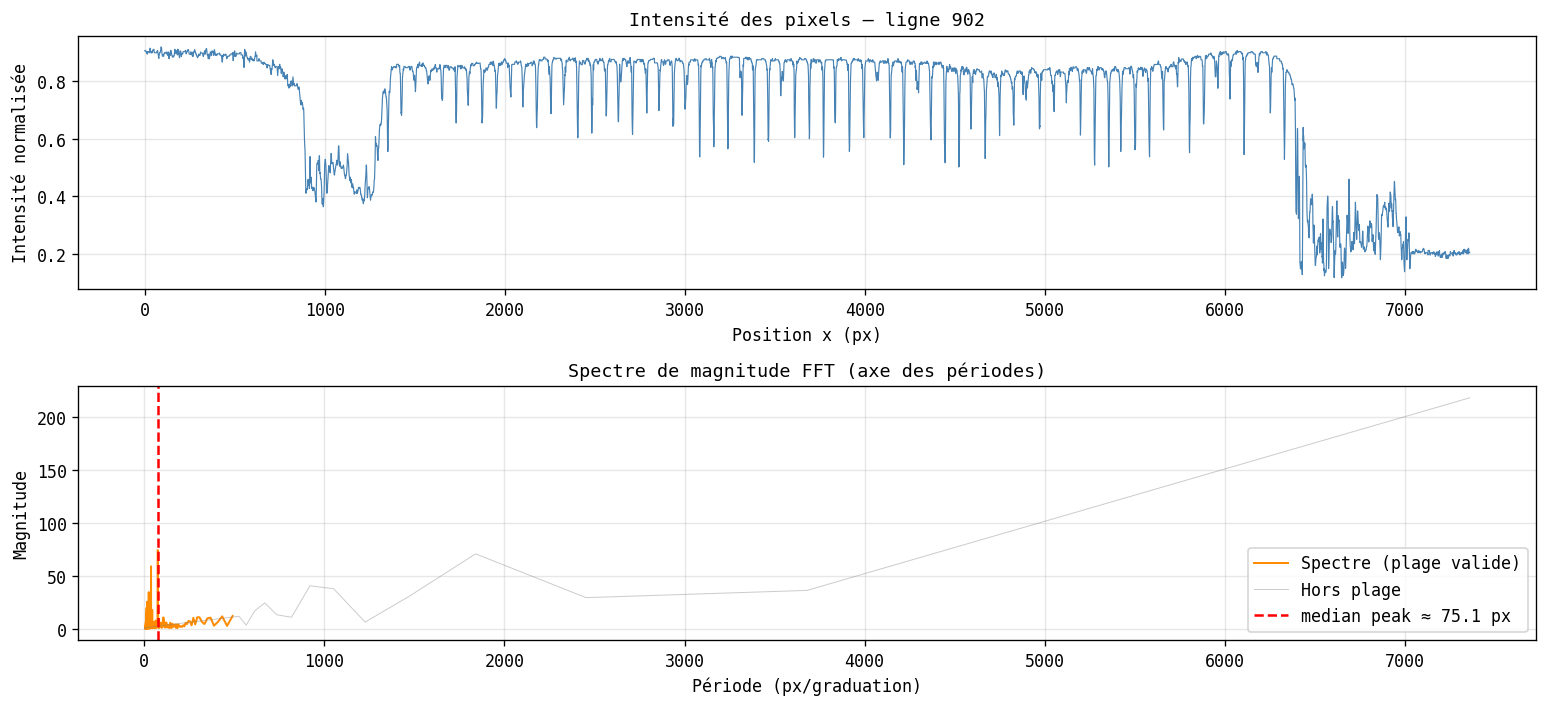

In [106]:
# ─────────────────────────────────────────────
# 5. VISUALISATION DU SPECTRE FFT (ligne médiane)
# ─────────────────────────────────────────────

# Affichage du spectre sur la ligne ou la magnitue atteinte est la plus grande  
mag_max = 0
max_idx = 0
for i in range(len(results)):
    mid_row  = results[i][0]
    if results[i][3] > mag_max:
        mag_max = results[i][3]
        max_idx = i

mid_row = results[max_idx][0]
row_demo = img_gray[mid_row, :]
N        = len(row_demo)

row_c = row_demo - row_demo.mean()
row_w = row_c * np.hanning(N)
fft_demo  = np.fft.rfft(row_w)
freqs_demo = np.fft.rfftfreq(N)
mag_demo  = np.abs(fft_demo)

# Conversion fréquence → période (px)
with np.errstate(divide='ignore'):
    periods_demo = np.where(freqs_demo > 0, 1.0 / freqs_demo, np.inf)

# Plage de périodes valides
valid_mask = (periods_demo >= MIN_FREQ_PX) & (periods_demo <= MAX_FREQ_PX)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

# — Ligne de pixels —
axes[0].plot(row_demo, color='steelblue', lw=0.7)
axes[0].set_title(f"Intensité des pixels — ligne {mid_row}", fontsize=11)
axes[0].set_xlabel("Position x (px)")
axes[0].set_ylabel("Intensité normalisée")
axes[0].grid(True, alpha=0.3)

# — Spectre FFT —
axes[1].plot(periods_demo[valid_mask], mag_demo[valid_mask],
             color='darkorange', lw=1.2, label='Spectre (plage valide)')
axes[1].plot(periods_demo[~valid_mask & (freqs_demo > 0)],
             mag_demo[~valid_mask & (freqs_demo > 0)],
             color='gray', lw=0.6, alpha=0.4, label='Hors plage')

# Marquer le pic dominant dans la plage valide
if len(results) > 0:
    dominant_period = periods_demo[valid_mask][np.argmax(mag_demo[valid_mask])]
    print(f"Max magnitude : {mag_demo[valid_mask].max():.2f}")
    print(f"dominant period : {dominant_period:.2f} px -> {dominant_period:.2f} px / mm")
    axes[1].axvline(dominant_period, color='red', ls='--', lw=1.5,
                    label=f'median peak ≈ {dominant_period:.1f} px')

axes[1].set_title("Spectre de magnitude FFT (axe des périodes)", fontsize=11)
axes[1].set_xlabel("Période (px/graduation)")
axes[1].set_ylabel("Magnitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Période médiane brute (axe X) : 75.102 px
Pente de phase (rad/px) : 0.001277

📐 Angle d'inclinaison estimé : 0.875°


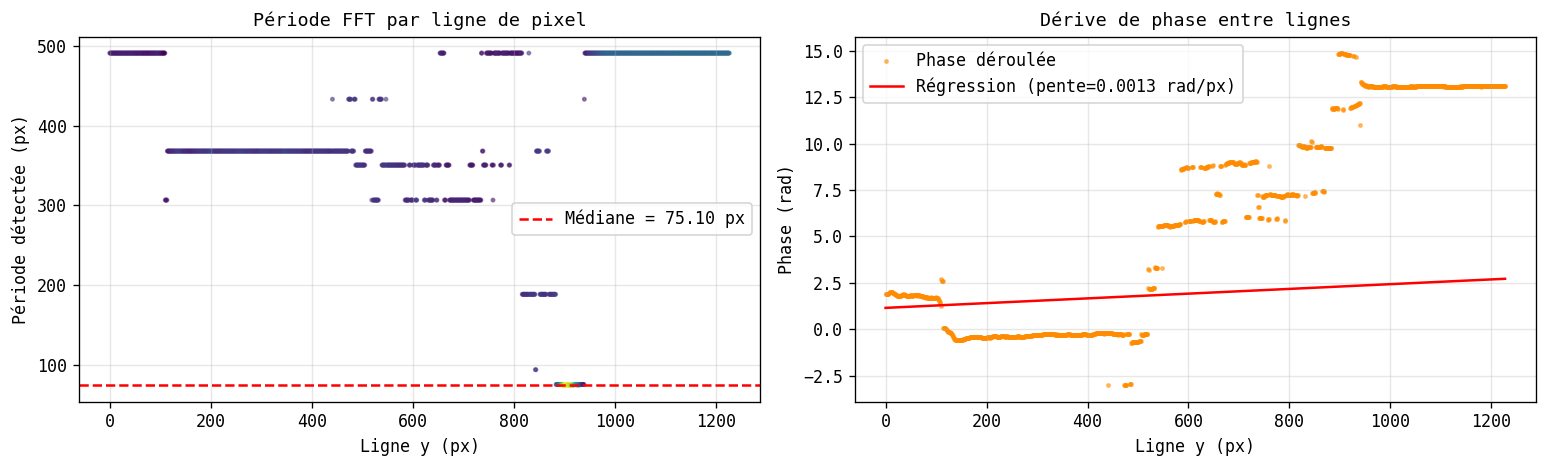

In [107]:
# ─────────────────────────────────────────────
# 6. ESTIMATION DE L'ANGLE D'INCLINAISON
# ─────────────────────────────────────────────
#
# Principe :
# Si la règle est inclinée d'un angle θ par rapport à l'horizontale,
# la phase du pic FFT va dériver d'une ligne à la suivante.
#
# La dérive de phase Δφ entre deux lignes séparées de Δy px est :
#   Δφ = 2π · tan(θ) · Δy / T_px
# où T_px est la période apparente (en px sur l'axe X).
#
# En mesurant la pente de phase dφ/dy sur toutes les lignes disponibles,
# on retrouve θ = arctan(slope_phase · T_px / 2π).
# ──────────────────────────────────────────────────────────────────────────

if len(results) < 5:
    raise RuntimeError("Pas assez de lignes avec un pic valide pour estimer l'angle.")

rows_arr   = np.array([r[0] for r in results], dtype=float)
phases_arr  = np.array([r[2] for r in results], dtype=float)
mag_arr = np.array([r[3] for r in results], dtype=float)

# filter les lignes ayant la même periode que la ligne de magnitude maximale
periods_arr = np.array([r[1] for r in results], dtype=float)
max_mag = max(mag_arr)
filtered_rows = []
filtered_phases = []
filtered_periods = []
for i in range(len(results)):
    if results[i][3] == max_mag:
        filtered_rows.append(results[i][0])
        filtered_phases.append(results[i][2])
        filtered_periods.append(results[i][1])
filtered_rows_arr = np.array(filtered_rows, dtype=float)
filtered_phases_arr = np.array(filtered_phases, dtype=float)
filtered_periods_arr = np.array(filtered_periods, dtype=float)


# ── 6a. Médiane robuste de la période ─────────────────────────────────────
# On utilise la médiane pour être robuste aux valeurs aberrantes
T_median = np.median(filtered_periods_arr)
print(f"Période médiane brute (axe X) : {T_median:.3f} px")

# ── 6b. Dérouillement de phase (unwrap) ───────────────────────────────────
# La phase est définie modulo 2π ; on la déroule pour obtenir
# une progression continue et mesurer sa pente.
phases_unwrapped = np.unwrap(filtered_phases_arr)

# ── 6c. Régression linéaire phase vs numéro de ligne ─────────────────────
# φ(y) = a·y + b  ⟹  a = dφ/dy = pente de phase
slope_phase, intercept_phase = np.polyfit(filtered_rows_arr, phases_unwrapped, 1)

print(f"Pente de phase (rad/px) : {slope_phase:.6f}")

# ── 6d. Calcul de l'angle θ ───────────────────────────────────────────────
# tan(θ) = slope_phase · T_median / (2π)
tan_theta = slope_phase * T_median / (2 * np.pi)
theta_rad = np.arctan(tan_theta)
theta_deg = np.degrees(theta_rad)

print(f"\n📐 Angle d'inclinaison estimé : {theta_deg:.3f}°")

# ── 6e. Visualisation de la dérive de phase ───────────────────────────────
# color is based on magnitude of the peak
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution des périodes détectées par ligne
axes[0].scatter(rows_arr, periods_arr, s=4, alpha=0.5, c=[res[3] for res in results], cmap='viridis',)
axes[0].axhline(T_median, color='red', ls='--', lw=1.5,
                label=f'Médiane = {T_median:.2f} px')
axes[0].set_title("Période FFT par ligne de pixel", fontsize=11)
axes[0].set_xlabel("Ligne y (px)")
axes[0].set_ylabel("Période détectée (px)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dérive de phase : données brutes + régression linéaire
axes[1].scatter(rows_arr, np.unwrap(phases_arr), s=4, alpha=0.5, color='darkorange',
                label='Phase déroulée')
y_fit = slope_phase * rows_arr + intercept_phase
axes[1].plot(rows_arr, y_fit, color='red', lw=1.5,
             label=f'Régression (pente={slope_phase:.4f} rad/px)')
axes[1].set_title("Dérive de phase entre lignes", fontsize=11)
axes[1].set_xlabel("Ligne y (px)")
axes[1].set_ylabel("Phase (rad)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [108]:
# ─────────────────────────────────────────────
# 7. CORRECTION TRIGONOMÉTRIQUE ET RÉSULTAT FINAL
# ─────────────────────────────────────────────
#
# Si la règle est inclinée de θ, la période mesurée T_px sur l'axe X
# est la projection de la vraie période T_reel :
#
#   T_px = T_reel · cos(θ)
#   ⟹  T_reel = T_px / cos(θ)
#
# La vraie période correspond à GRADUATION_MM millimètres.
# Donc :
#   px_per_mm = T_reel / GRADUATION_MM
#   mm_per_px = GRADUATION_MM / T_reel
# ──────────────────────────────────────────────────────────────────────────

# Correction de la période par l'angle
T_corrected = T_median / np.cos(theta_rad)

# Ratios finaux
px_per_mm = T_corrected / GRADUATION_MM
mm_per_px = GRADUATION_MM / T_corrected

# ── Rapport complet ───────────────────────────────────────────────────────
separator = "─" * 50
print(separator)
print("          RÉSULTATS DE L'ANALYSE")
print(separator)
print(f"  Graduation de la règle       : {GRADUATION_MM:.2f} mm")
print(f"  Période brute (axe X)        : {T_median:.3f} px")
print(f"  Angle d'inclinaison          : {theta_deg:.3f} °")
print(f"  Période corrigée             : {T_corrected:.3f} px")
print(separator)
print(f"  ➤  px / mm                  : {px_per_mm:.4f} px/mm")
print(f"  ➤  mm / px                  : {mm_per_px:.6f} mm/px")
print(separator)

──────────────────────────────────────────────────
          RÉSULTATS DE L'ANALYSE
──────────────────────────────────────────────────
  Graduation de la règle       : 1.00 mm
  Période brute (axe X)        : 75.102 px
  Angle d'inclinaison          : 0.875 °
  Période corrigée             : 75.111 px
──────────────────────────────────────────────────
  ➤  px / mm                  : 75.1108 px/mm
  ➤  mm / px                  : 0.013314 mm/px
──────────────────────────────────────────────────


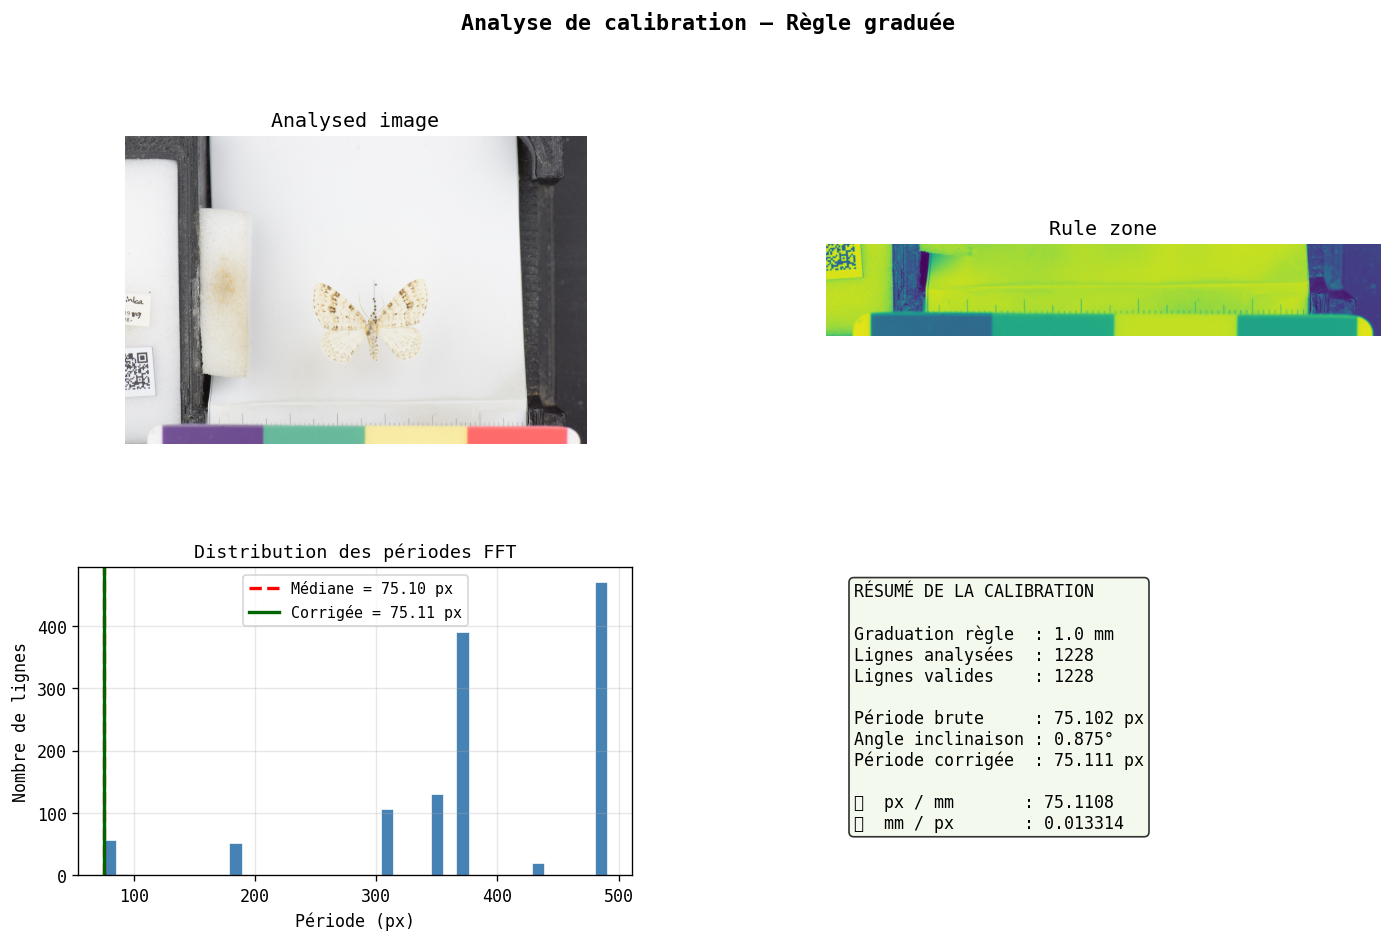


🎉 Analyse terminée avec succès.


In [ ]:
# ─────────────────────────────────────────────
# 8. VISUALISATION RÉCAPITULATIVE FINALE
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 8a. Image originale avec indication de la règle ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(base_img_color)
ax1.set_title("Analysed image", fontsize=12)
ax1.axis('off')

# Ajouter une annotation avec le résultat
info = (f"  mm/px = {mm_per_px:.5f}  |  px/mm = {px_per_mm:.3f}  "
        f"|  angle = {theta_deg:.2f}°  ")
ax1.set_xlabel(info, fontsize=10, labelpad=6)
ax1.xaxis.label.set_color('darkgreen')

#
ax4 = fig.add_subplot(gs[0, 1])
ax4.imshow(img_gray)
ax4.set_title("Ruler zone", fontsize=12)
ax4.axis('off')

# Ajouter une annotation avec le résultat
info = (f"  mm/px = {mm_per_px:.5f}  |  px/mm = {px_per_mm:.3f}  "
        f"|  angle = {theta_deg:.2f}°  ")
ax4.set_xlabel(info, fontsize=10, labelpad=6)
ax4.xaxis.label.set_color('darkgreen')

# ── 8b. Histogramme des périodes détectées ───────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(periods_arr, bins=40, color='steelblue', edgecolor='white', lw=0.4)
ax2.axvline(T_median, color='red', ls='--', lw=2,
            label=f'Médiane = {T_median:.2f} px')
ax2.axvline(T_corrected, color='darkgreen', ls='-', lw=2,
            label=f'Corrigée = {T_corrected:.2f} px')
ax2.set_title("Distribution des périodes FFT", fontsize=11)
ax2.set_xlabel("Période (px)")
ax2.set_ylabel("Nombre de lignes")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── 8c. Récapitulatif textuel ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
summary_lines = [
    "RÉSUMÉ DE LA CALIBRATION",
    "",
    f"Graduation règle  : {GRADUATION_MM} mm",
    f"Lignes analysées  : {len(row_indices)}",
    f"Lignes valides    : {len(results)}",
    "",
    f"Période brute     : {T_median:.3f} px",
    f"Angle inclinaison : {theta_deg:.3f}°",
    f"Période corrigée  : {T_corrected:.3f} px",
    "",
    f"⟹  px / mm       : {px_per_mm:.4f}",
    f"⟹  mm / px       : {mm_per_px:.6f}",
]
summary_text = "\n".join(summary_lines)
ax3.text(0.05, 0.95, summary_text,
         transform=ax3.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f8e8', alpha=0.8))

plt.suptitle("Analyse de calibration — Règle graduée",
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

print("\n🎉 Analyse terminée avec succès.")

In [110]:
# ─────────────────────────────────────────────
# 9. (BONUS) CONVERTISSEUR : pixels ↔ millimètres
# ─────────────────────────────────────────────

def px_to_mm(pixels: float) -> float:
    """Convertit une distance en pixels vers des millimètres."""
    return pixels * mm_per_px

def mm_to_px(millimeters: float) -> float:
    """Convertit une distance en millimètres vers des pixels."""
    return millimeters * px_per_mm

# Exemples d'utilisation
print("── Exemples de conversion ──────────────────")
for px_val in [50, 100, 200, 500]:
    print(f"  {px_val:5d} px  ≙  {px_to_mm(px_val):8.3f} mm")

print()
for mm_val in [1, 5, 10, 25]:
    print(f"  {mm_val:5d} mm  ≙  {mm_to_px(mm_val):8.2f} px")

── Exemples de conversion ──────────────────
     50 px  ≙     0.666 mm
    100 px  ≙     1.331 mm
    200 px  ≙     2.663 mm
    500 px  ≙     6.657 mm

      1 mm  ≙     75.11 px
      5 mm  ≙    375.55 px
     10 mm  ≙    751.11 px
     25 mm  ≙   1877.77 px
